# 03 — From Black–Scholes to Stochastic Volatility

**Quantitative Markets Research Lab** · flagship derivatives notebook

Black–Scholes (1973) is one of the most successful wrong models ever built. It is wrong in ways that are visible in ten lines of data analysis, and successful because everything that came after it — Heston, SABR, local vol, rough vol — is best understood as a patch written in its language. This notebook walks that arc deliberately:

1. State the Black–Scholes assumptions precisely and price a call.
2. Confront the two assumptions that matter most — constant volatility and Gaussian returns — with eleven years of real SPY data.
3. Replace constant $\sigma$ with a mean-reverting stochastic variance (Heston) and watch the implied-volatility *smile* appear where Black–Scholes insists on a flat line.
4. Simulate Heston paths to see the mechanism (volatility clustering, leverage effect) rather than just its pricing consequences.
5. Quantify the disagreement: a BS-vs-Heston price divergence table across strikes and maturities.
6. Use SABR to show how a smile's *shape* is controlled by two interpretable parameters.
7. End where every derivatives desk lives: model risk.

## 1. The Black–Scholes world, stated honestly

The model assumes:

1. **Geometric Brownian motion**: $dS_t = \mu S_t\,dt + \sigma S_t\,dW_t$ with $\sigma$ a *known constant* — volatility never changes, returns are i.i.d. Gaussian at every horizon.
2. **Frictionless markets**: continuous trading, no transaction costs, no bid–ask spread, unlimited shorting, one riskless rate $r$ for lending and borrowing.
3. **No jumps**: sample paths are continuous; the market never gaps.
4. **No arbitrage**, so the option is redundant: a continuously rebalanced portfolio of stock and bond replicates it exactly, and the price is the discounted risk-neutral expectation

$$C(S_0,K,T) = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\big[(S_T-K)^+\big] = S_0 N(d_1) - K e^{-rT} N(d_2).$$

Assumption 1 has a sharp observable fingerprint. If $\sigma$ is constant, then the implied volatility extracted from market option prices must be **the same number at every strike and maturity** — a flat surface. It is not, and has not been since October 1987. The rest of this notebook is about that gap.

In [1]:
import sys, os, pathlib

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.figsize": (9.5, 5), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
SEED = 42

from src.models.black_scholes import bs_price, implied_vol
from src.models.heston_model import HestonParams, heston_price, simulate_heston
from src.models.stochastic_volatility import sabr_implied_vol
from src.data.market_data_loader import load_prices, to_returns

In [2]:
# Price a 1-year at-the-money call under Black-Scholes.
S0, r = 100.0, 0.03
sigma_bs = 0.20     # the single number the model asks us to know
c_atm = bs_price(S0, 100.0, 1.0, r, sigma_bs)
print(f"BS 1y ATM call, sigma = {sigma_bs:.0%}:  {c_atm:.4f}")
print(f"  -> roughly S0 * 0.4 * sigma * sqrt(T) = {S0 * 0.4 * sigma_bs:.2f}  (the trader's approximation)")

BS 1y ATM call, sigma = 20%:  9.4134
  -> roughly S0 * 0.4 * sigma * sqrt(T) = 8.00  (the trader's approximation)


One input carries all the risk: $\sigma$. The model does not merely require us to estimate it; it requires it to *be a constant of nature*. Let us check.

## 2. What eleven years of SPY actually look like

We use the cached SPY history (2015-01 to 2026-07, ~2,900 daily observations) and test the two Gaussian-GBM fingerprints:

- **Constant volatility** implies the rolling realized vol is a noisy but flat line, and that squared or absolute returns have no autocorrelation.
- **Gaussian returns** imply skewness $\approx 0$ and excess kurtosis $\approx 0$, with the largest daily move in ~11 years around $4$–$4.5$ standard deviations.

rolling 21d vol:  min 3.4%,  max 93.0%  (a factor of 27x)


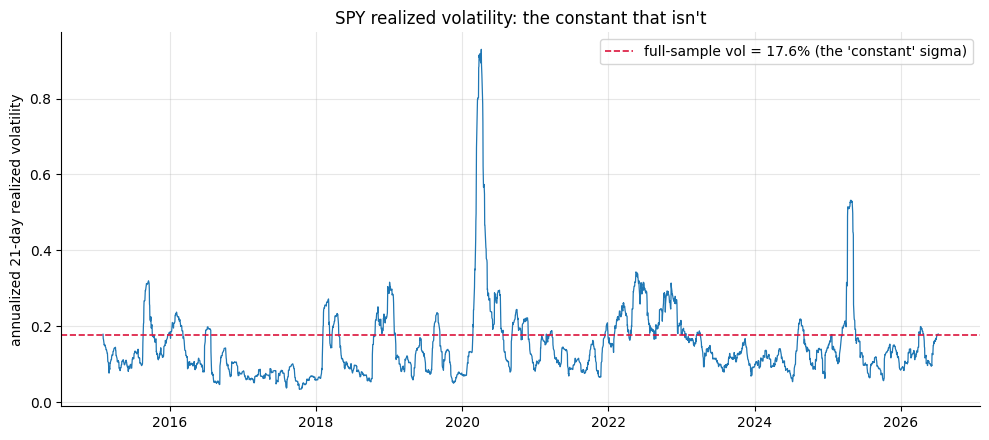

In [3]:
spy = to_returns(load_prices(["SPY"]))["SPY"]
ann_vol = spy.std() * np.sqrt(252)
roll_vol = spy.rolling(21).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(roll_vol, lw=0.9)
ax.axhline(ann_vol, color="crimson", ls="--", lw=1.2,
           label=f"full-sample vol = {ann_vol:.1%} (the 'constant' sigma)")
ax.set_ylabel("annualized 21-day realized volatility")
ax.set_title("SPY realized volatility: the constant that isn't")
ax.legend()
plt.tight_layout()

print(f"rolling 21d vol:  min {roll_vol.min():.1%},  max {roll_vol.max():.1%}  "
      f"(a factor of {roll_vol.max()/roll_vol.min():.0f}x)")

The "constant" ranges from about **3%** (mid-2017) to about **93%** (March 2020) — a factor of nearly thirty. And the variation is not white noise around a mean: high-vol days cluster into episodes (late-2018, Covid, the 2022 rate shock, spring 2025). Mandelbrot's 1963 observation stands: *large changes tend to be followed by large changes, of either sign.*

worst single day: -10.94%  (9.8 sigma)
Gaussian probability of a move that size on a given day: 3.63e-23


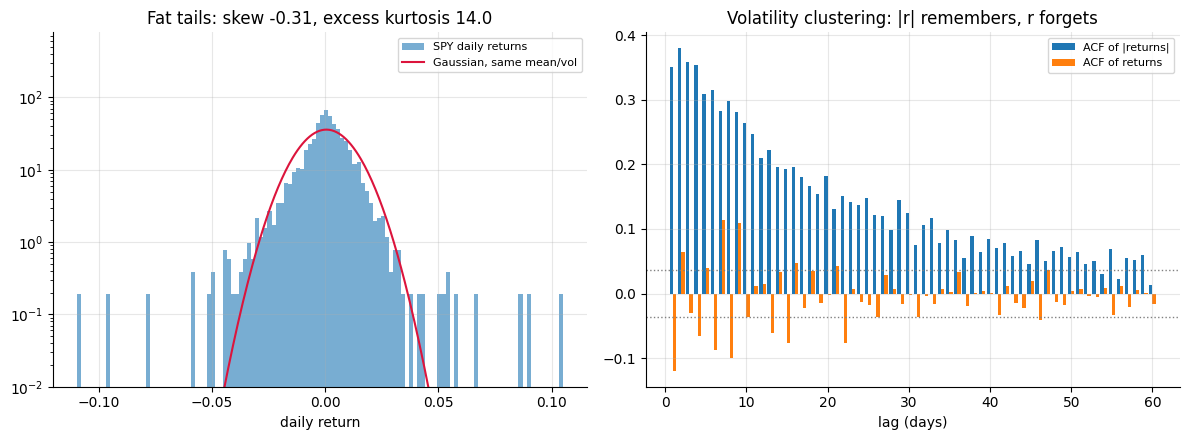

In [4]:
r_ = spy.dropna()
skew, exkurt = stats.skew(r_), stats.kurtosis(r_)
worst = r_.min() / r_.std()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: return distribution vs the Gaussian, log scale to expose the tails.
x = np.linspace(r_.min(), r_.max(), 400)
axes[0].hist(r_, bins=120, density=True, alpha=0.6, label="SPY daily returns")
axes[0].plot(x, stats.norm.pdf(x, r_.mean(), r_.std()), "crimson", lw=1.5,
             label="Gaussian, same mean/vol")
axes[0].set_yscale("log")
axes[0].set_ylim(bottom=1e-2)
axes[0].set_title(f"Fat tails: skew {skew:.2f}, excess kurtosis {exkurt:.1f}")
axes[0].set_xlabel("daily return")
axes[0].legend(fontsize=8)

# Right: volatility clustering via autocorrelation of |r| vs r.
lags = np.arange(1, 61)
acf_abs = [r_.abs().autocorr(l) for l in lags]
acf_raw = [r_.autocorr(l) for l in lags]
ci = 1.96 / np.sqrt(len(r_))
axes[1].bar(lags - 0.2, acf_abs, width=0.4, label="ACF of |returns|")
axes[1].bar(lags + 0.2, acf_raw, width=0.4, label="ACF of returns")
axes[1].axhline(ci, color="gray", ls=":", lw=1); axes[1].axhline(-ci, color="gray", ls=":", lw=1)
axes[1].set_title("Volatility clustering: |r| remembers, r forgets")
axes[1].set_xlabel("lag (days)")
axes[1].legend(fontsize=8)
plt.tight_layout()

print(f"worst single day: {r_.min():.2%}  ({abs(worst):.1f} sigma)")
p_gauss = stats.norm.sf(abs(worst))
print(f"Gaussian probability of a move that size on a given day: {p_gauss:.2e}")

**Two clean rejections.**

- **Fat tails.** Excess kurtosis is about **14** against a Gaussian's 0. The worst day in the sample (−10.9%, March 2020) is a ≈ **10-sigma** event; under normality its single-day probability is around $10^{-23}$ — you would not expect one in billions of times the age of the universe, and SPY produced several 5σ+ days in a single decade. The log-scale histogram makes the point without arithmetic: the empirical tails sit far above the red curve.
- **Volatility clustering.** Raw returns are nearly uncorrelated (lag-1 ACF ≈ −0.12, and small beyond) — direction is hard to predict. But *absolute* returns show autocorrelation of ≈ 0.35 at lag 1, decaying slowly and staying significant past lag 50 — the **magnitude** of tomorrow's move is very predictable from today's. That is precisely the signature of a volatility process with its own persistent dynamics.

These two facts jointly indict assumption 1. The natural repair is to promote $\sigma$ from a constant to a *process*.

## 3. Heston: volatility as a mean-reverting process

Heston (1993) models variance $v_t$ as a CIR square-root diffusion, correlated with the price:

$$dS_t = r\,S_t\,dt + \sqrt{v_t}\,S_t\,dW^S_t, \qquad
dv_t = \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW^v_t, \qquad
d\langle W^S, W^v\rangle_t = \rho\,dt.$$

Five parameters, each with a job: $v_0$ (today's variance), $\theta$ (long-run variance), $\kappa$ (mean-reversion speed), $\xi$ (vol-of-vol — how fat the tails get), and $\rho$ (price–vol correlation — for equities strongly negative: crashes and vol spikes arrive together, the *leverage effect*). The Feller condition $2\kappa\theta \ge \xi^2$ keeps variance strictly positive.

The model retains a semi-analytic price via the characteristic function (the library integrates the numerically stable "little trap" formulation with Gauss–Legendre quadrature), which makes the next experiment cheap: price options across strikes under Heston, then ask *what constant Black–Scholes volatility would reproduce each price* — the implied vol. If the world were Black–Scholes, the answer would not depend on the strike.

Feller condition 2*kappa*theta >= xi^2 : 0.180 >= 0.122 -> True


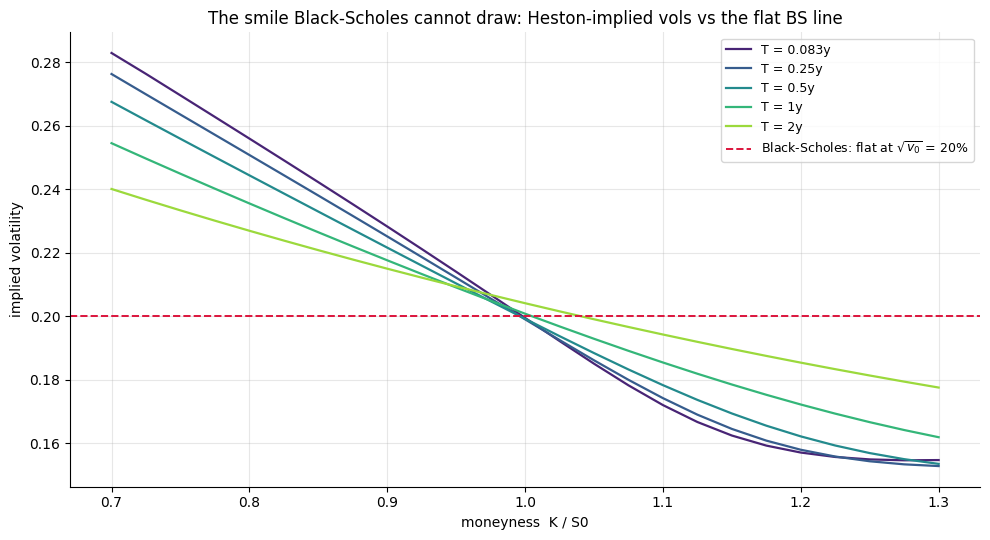

In [5]:
params = HestonParams(v0=0.04, kappa=2.0, theta=0.045, xi=0.35, rho=-0.70)
print(f"Feller condition 2*kappa*theta >= xi^2 : "
      f"{2*params.kappa*params.theta:.3f} >= {params.xi**2:.3f} -> {params.feller_satisfied}")

strikes = np.linspace(70, 130, 25)
maturities = [0.083, 0.25, 0.5, 1.0, 2.0]

smile = pd.DataFrame(index=strikes, columns=maturities, dtype=float)
for T in maturities:
    for K in strikes:
        p = heston_price(S0, float(K), T, r, params)
        smile.loc[K, T] = implied_vol(p, S0, float(K), T, r)

fig, ax = plt.subplots(figsize=(10, 5.5))
cmap = plt.cm.viridis(np.linspace(0.1, 0.85, len(maturities)))
for c, T in zip(cmap, maturities):
    ax.plot(strikes / S0, smile[T], color=c, lw=1.6, label=f"T = {T:g}y")
ax.axhline(np.sqrt(params.v0), color="crimson", ls="--", lw=1.4,
           label=r"Black-Scholes: flat at $\sqrt{v_0}$ = 20%")
ax.set_xlabel("moneyness  K / S0")
ax.set_ylabel("implied volatility")
ax.set_title("The smile Black-Scholes cannot draw: Heston-implied vols vs the flat BS line")
ax.legend(fontsize=9)
plt.tight_layout()

**Interpretation.** Every curve is generated by a *single* self-consistent model — yet translated into Black–Scholes language it needs a different $\sigma$ for every contract. Three features to notice, all present in real equity-index surfaces:

- **The skew.** With $\rho = -0.7$, downside strikes (K/S₀ ≈ 0.8) trade near **25% vol** while upside strikes (K/S₀ ≈ 1.2) trade near **16%** at short maturity. Puts are expensive because the model knows — as the market does — that down-moves and vol spikes are the same event.
- **Term flattening.** The 1-month curve is steep; the 2-year curve is gentle. Over long horizons variance averages toward $\theta$ and the CLT partially reasserts itself, so far-dated implied vols compress toward $\sqrt{\theta} \approx 21\%$.
- **The level anchors.** Short-dated ATM vol sits near $\sqrt{v_0} = 20\%$; long-dated vol drifts toward the long-run mean. The whole surface is a term structure of how fast today's variance forgets itself ($\kappa$).

## 4. Watching the mechanism: simulated Heston paths

Pricing formulas hide the dynamics. Simulation shows them: the same parameters that bend the smile also generate the clustering and fat tails of Section 2.

terminal 2y log-returns: skew -0.87, excess kurtosis 1.30  (GBM would give ~0, 0)


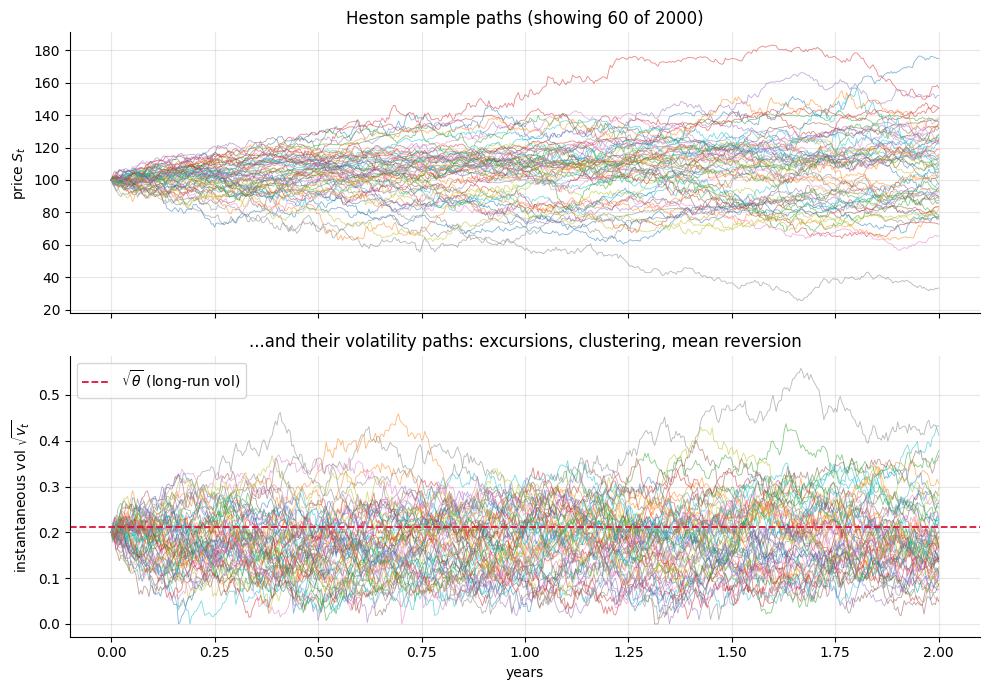

In [6]:
rng = np.random.default_rng(SEED)
S_paths, v_paths = simulate_heston(S0, params, r, T=2.0, n_steps=504, n_paths=2000, rng=rng)
t = np.linspace(0, 2.0, 505)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
show = 60
axes[0].plot(t, S_paths[:show].T, lw=0.6, alpha=0.55)
axes[0].set_ylabel("price $S_t$")
axes[0].set_title(f"Heston sample paths (showing {show} of {S_paths.shape[0]})")

axes[1].plot(t, np.sqrt(np.clip(v_paths[:show].T, 0, None)), lw=0.6, alpha=0.55)
axes[1].axhline(np.sqrt(params.theta), color="crimson", ls="--", lw=1.3,
                label=r"$\sqrt{\theta}$ (long-run vol)")
axes[1].set_ylabel(r"instantaneous vol $\sqrt{v_t}$")
axes[1].set_xlabel("years")
axes[1].set_title("...and their volatility paths: excursions, clustering, mean reversion")
axes[1].legend()
plt.tight_layout()

log_ret = np.log(S_paths[:, -1] / S0)
print(f"terminal 2y log-returns: skew {stats.skew(log_ret):.2f}, "
      f"excess kurtosis {stats.kurtosis(log_ret):.2f}  (GBM would give ~0, 0)")

The volatility panel is the point: individual paths spend long stretches below $\sqrt\theta$ and then spike into sustained high-vol episodes — the simulated cousin of the SPY realized-vol chart in Section 2. The negative correlation feeds those episodes into the price paths as clustered, left-skewed shocks; the terminal distribution inherits negative skew and positive excess kurtosis without any of it being put in by hand.

(Simulation here uses full-truncation Euler, which is biased for finite step size — one reason the semi-analytic pricer, not the simulator, is used for the pricing tables.)

## 5. How much does the model choice cost? A divergence table

Suppose the world is Heston but a desk prices with Black–Scholes calibrated to the ATM vol. The table shows Heston price minus BS price (per 100 of spot), and the same gap expressed in implied-vol points.

In [7]:
tab_strikes = [70, 85, 100, 115, 130]
tab_mats = [0.25, 0.5, 1.0, 2.0]
sigma_atm = float(smile.loc[100.0, 0.25])   # desk calibrates BS to short-dated ATM

price_diff = pd.DataFrame(index=tab_mats, columns=tab_strikes, dtype=float)
vol_diff = pd.DataFrame(index=tab_mats, columns=tab_strikes, dtype=float)
for T in tab_mats:
    for K in tab_strikes:
        h = heston_price(S0, float(K), T, r, params)
        b = bs_price(S0, float(K), T, r, sigma_atm)
        price_diff.loc[T, K] = h - b
        vol_diff.loc[T, K] = implied_vol(h, S0, float(K), T, r) - sigma_atm
price_diff.index.name = "T (years) \ strike"
vol_diff.index.name = "T (years) \ strike"

print(f"BS calibrated to sigma_ATM(3m) = {sigma_atm:.4f}\n")
print("Heston - BS price difference (per S0 = 100):")
display(price_diff.round(3))
print("same gap in implied-vol points:")
display((vol_diff * 100).round(2))

BS calibrated to sigma_ATM(3m) = 0.1991

Heston - BS price difference (per S0 = 100):


,70,85,100,115,130
T (years) \ strike,,,,,
0.25,0.015,0.212,-0.000,-0.254,-0.018
0.50,0.131,0.444,0.005,-0.560,-0.205
1.00,0.424,0.655,0.069,-0.727,-0.721
2.00,0.753,0.821,0.269,-0.521,-0.995


same gap in implied-vol points:


,70,85,100,115,130
T (years) \ strike,,,,,
0.25,7.73,3.90,0.00,-3.45,-4.62
0.50,6.85,3.39,0.02,-2.96,-4.55
1.00,5.55,2.74,0.18,-2.05,-3.71
2.00,4.11,2.18,0.51,-0.93,-2.15


**Interpretation.** At the money, the two models nearly agree — that is what calibration *means*. The disagreement lives in the wings and grows with maturity: deep OTM puts (K = 70) are underpriced by flat-vol BS by several vol points, and the error changes *sign* across the strike range, so it cannot be fixed by shifting the single $\sigma$ up or down. A desk selling 25-delta puts at BS-flat vol in a Heston world systematically collects too little premium for the crash risk it is warehousing. The dollar numbers look small per option; books are measured in thousands of vega-weighted contracts.

## 6. SABR: the smile's control knobs

Hagan et al. (2002) model the forward $F_t$ with stochastic volatility $\alpha_t$:

$$dF_t = \alpha_t F_t^{\beta}\,dW^1_t, \qquad d\alpha_t = \nu\,\alpha_t\,dW^2_t, \qquad d\langle W^1,W^2\rangle_t = \rho\,dt,$$

and — the reason for its ubiquity on rates and FX desks — give a closed-form *implied volatility* expansion, so the smile is the model's native output rather than something extracted numerically. With $\beta = 1$ (lognormal backbone), the two shape parameters act almost orthogonally: $\rho$ **tilts** the smile, $\nu$ **curves** it.

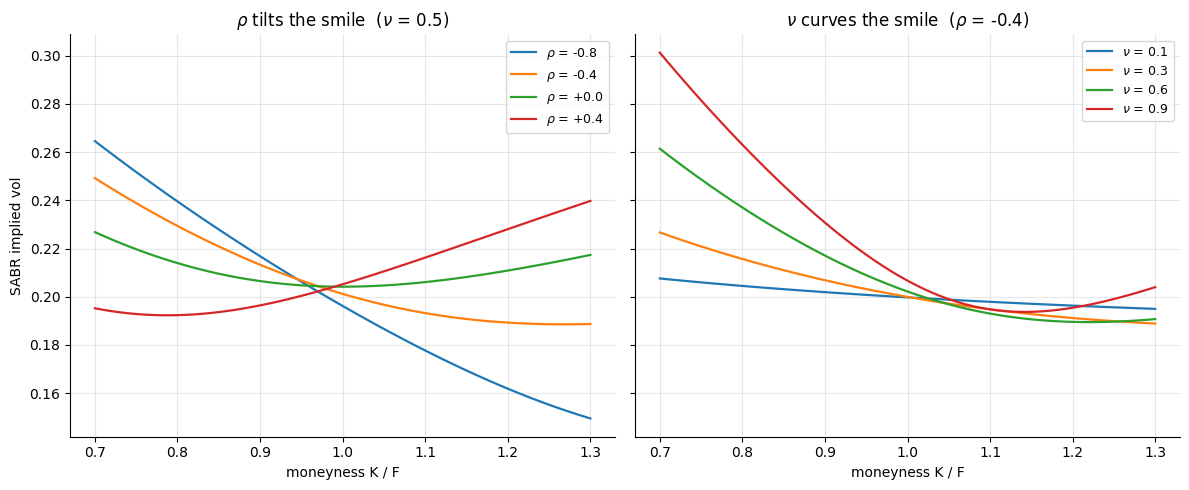

In [8]:
F, T_sabr, alpha, beta = 100.0, 1.0, 0.20, 1.0
Ks = np.linspace(70, 130, 61)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for rho_ in (-0.8, -0.4, 0.0, 0.4):
    ivs = [sabr_implied_vol(F, float(K), T_sabr, alpha, beta, rho_, 0.5) for K in Ks]
    axes[0].plot(Ks / F, ivs, lw=1.6, label=fr"$\rho$ = {rho_:+.1f}")
axes[0].set_title(r"$\rho$ tilts the smile  ($\nu$ = 0.5)")
axes[0].set_xlabel("moneyness K / F"); axes[0].set_ylabel("SABR implied vol")
axes[0].legend(fontsize=9)

for nu_ in (0.1, 0.3, 0.6, 0.9):
    ivs = [sabr_implied_vol(F, float(K), T_sabr, alpha, beta, -0.4, nu_) for K in Ks]
    axes[1].plot(Ks / F, ivs, lw=1.6, label=fr"$\nu$ = {nu_:.1f}")
axes[1].set_title(r"$\nu$ curves the smile  ($\rho$ = -0.4)")
axes[1].set_xlabel("moneyness K / F")
axes[1].legend(fontsize=9)
plt.tight_layout()

**Interpretation.** In the left panel, sweeping $\rho$ from $-0.8$ to $+0.4$ rotates the smile from a steep equity-style put skew to an upward commodity-style call skew, with the ATM point barely moving. In the right panel, raising vol-of-vol $\nu$ deepens the convexity symmetrically — both wings rise, because uncertainty about volatility itself makes *all* far-from-the-money options more valuable. This interpretability is exactly why traders quote smiles in SABR parameters: "rho richened" is a sentence; a 61-point vol vector is not.

## 7. Model risk: the honest conclusion

The arc of this notebook is worth restating as a chain of admissions:

- **Black–Scholes assumes one volatility.** SPY's realized vol ranged from 3% to 93% in our sample, with clustering visible fifty trading days out, and an 11σ day where the model allows essentially none.
- **Heston repairs this** — stochastic, mean-reverting, correlated variance reproduces the skew, the clustering, and the fat tails with five parameters. But look at what it assumes in turn: $\kappa, \theta, \xi, \rho$ are *constants*. Heston commits, one level up, exactly the sin it corrects in Black–Scholes. In real markets these "constants" are recalibrated daily, which is the market's way of saying the model is wrong but usefully parameterized.
- **SABR is not a truth claim at all** — practitioners use it as a smooth, arbitrage-aware *interpolator* of the smile, recalibrated per expiry. Its parameters are a coordinate system for quotes, not physics.

The practical discipline that follows: (i) never let a model price contracts far from where it was calibrated — the divergence table shows the wings are where models disagree most; (ii) hedge against the *smile you observe*, not the model's smile (BS delta vs smile-adjusted delta can differ materially at 25-delta); (iii) treat parameter recalibration velocity as a model-risk metric — a "constant" you move every day is a state variable you have chosen not to model.

Every model in this notebook is a lens with known distortions. The craft is not finding the undistorted lens — there isn't one — but knowing which distortion you can afford for the contract in front of you. Models clarify uncertainty; they do not eliminate it.

---

**References.** Black & Scholes (1973), *JPE* 81(3) · Heston (1993), *RFS* 6(2) · Hagan, Kumar, Lesniewski & Woodward (2002), "Managing Smile Risk," *Wilmott* · Mandelbrot (1963), *J. Business* 36 · Gatheral (2006), *The Volatility Surface* · Cont (2001), "Empirical properties of asset returns," *Quant. Finance* 1.